In [ ]:
import numpy as np 
import pandas as pd
import os

In [ ]:
!pip install transformers --quiet
!pip install evaluate --quiet
!pip install rouge-score --quiet
!pip install nltk --quiet

print("All libraries installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.7 MB/s eta 0:00:00a 0:00:01
All libraries installed!


In [3]:
import os
import json
import random
import time
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.ops as ops

from transformers import BertTokenizer

import evaluate
import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

print("All imports successful!")
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

All imports successful!
PyTorch version : 2.10.0+cu128
CUDA available  : True


In [ ]:

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

IMAGE_SIZE = 224         

NUM_REGIONS = 29          
                          

LESION_CLASSES = [
    "lung_opacity",
    "atelectasis",
    "pleural_effusion",
    "pulmonary_edema_hazy_opacity",
    "consolidation",
    "pneumothorax",
    "enlarged_cardiac_silhouette",
    "tortuous_aorta",
    "vascular_calcification",
    "hyperaeration",
    "lung_lesion",
    "mass_nodule",
    "pleural_parenchymal_scarring",
    "vascular_congestion",
    "mediastinal_widening",
    "enlarged_hilum",
    "airspace_opacity",
    "costophrenic_angle_blunting",
    "lobar_segmental_collapse",
    "linear_patchy_atelectasis",
    "vascular_redistribution",
]
NUM_LESIONS = len(LESION_CLASSES) 

MAX_SEQ_LEN   = 128    
MAX_FINDINGS  = 128
MAX_IMPRESSION = 128

BATCH_SIZE    = 8          
EPOCHS        = 30         
LR_DETECTOR   = 1e-3      
LR_FULL_MODEL = 5e-5   
WEIGHT_DECAY_S1 = 1e-2    
WEIGHT_DECAY_S2 = 0.05     

CONFIDENCE_THRESHOLD = 0.35   
IOU_THRESHOLD        = 0.45  
IOU_ASSIGN_THRESHOLD = 0.4    

BERT_HIDDEN  = 512        
BEAM_WIDTH   = 4         

BASE_PATH = "/kaggle/input/curated-cxr-report-generation-dataset"
IMG_BASE  = os.path.join(BASE_PATH, "mimic_dset/re_512_3ch")
SAVE_PATH = "/kaggle/working"
os.makedirs(SAVE_PATH, exist_ok=True)

print(f"\nPaper settings loaded:")
print(f"  NUM_REGIONS          : {NUM_REGIONS}  (paper: 29)")
print(f"  NUM_LESIONS          : {NUM_LESIONS}  (paper: 21 after class reduction)")
print(f"  BERT_HIDDEN          : {BERT_HIDDEN}  (paper: 1024, reduced for GPU)")
print(f"  IMAGE_SIZE           : {IMAGE_SIZE}   (paper: 512, reduced for GPU)")
print(f"  CONFIDENCE_THRESHOLD : {CONFIDENCE_THRESHOLD}")
print(f"  IOU_ASSIGN_THRESHOLD : {IOU_ASSIGN_THRESHOLD} ")
print(f"  BEAM_WIDTH           : {BEAM_WIDTH}   ")

Using device: cuda

Paper settings loaded:
  NUM_REGIONS          : 29  (paper: 29)
  NUM_LESIONS          : 21  (paper: 21 after class reduction)
  BERT_HIDDEN          : 512  (paper: 1024, reduced for GPU)
  IMAGE_SIZE           : 224   (paper: 512, reduced for GPU)
  CONFIDENCE_THRESHOLD : 0.35
  IOU_ASSIGN_THRESHOLD : 0.4 
  BEAM_WIDTH           : 4   


In [5]:
BASE_PATH = "/kaggle/input/datasets/financekim/curated-cxr-report-generation-dataset"

IMG_BASE  = os.path.join(BASE_PATH, "mimic_dset/re_512_3ch")

print("Building image lookup...")
image_lookup = {}
for folder in ["Train", "Valid", "Test"]:
    fp = os.path.join(IMG_BASE, folder)
    if os.path.exists(fp):
        for fname in os.listdir(fp):
            if fname.endswith(".jpg"):
                image_lookup[fname] = os.path.join(fp, fname)
print(f"Total images found: {len(image_lookup):,}")

def load_jsonl(filepath):
    rows = []
    with open(filepath, "r") as f:
        for line in f:
            entry    = json.loads(line)
            text     = entry.get("text",  "").strip()
            label    = entry.get("label", "").strip()
            img_id   = entry.get("id",    "")
            img_path = image_lookup.get(f"{img_id}.jpg", None)
            if img_path is None:      continue
            if not text or not label: continue
            if label in ["", "''"]:  continue
            rows.append({
                "id"         : img_id,
                "findings"   : text,
                "impression" : label,
                "path"       : img_path
            })
    return pd.DataFrame(rows)

MIMIC_PATH = os.path.join(
    BASE_PATH,
    "MedViLL-master/MedViLL-master/data/mimic"
)


train_df = load_jsonl(os.path.join(MIMIC_PATH, "Train.jsonl"))
val_df   = load_jsonl(os.path.join(MIMIC_PATH, "Valid.jsonl"))
test_df  = load_jsonl(os.path.join(MIMIC_PATH, "Test.jsonl"))

print(f"\nDataset loaded:")
print(f"  Train : {len(train_df):,}")
print(f"  Val   : {len(val_df):,}")
print(f"  Test  : {len(test_df):,}")

Building image lookup...
Total images found: 91,908

Dataset loaded:
  Train : 87,064
  Val   : 733
  Test  : 1,489


In [6]:
row = train_df.iloc[0]
print(f"Sample ID         : {row['id']}")
print(f"Sample Findings   : {row['findings'][:250]}")
print(f"Sample Impression : {row['impression'][:150]}")
print(f"Image path        : {row['path']}")
print(f"Image exists      : {os.path.exists(row['path'])}")

train_df["findings_wc"]   = train_df["findings"].str.split().str.len()
train_df["impression_wc"] = train_df["impression"].str.split().str.len()
print(f"\nFindings word count   — mean: {train_df['findings_wc'].mean():.1f}, "
      f"max: {train_df['findings_wc'].max()}")
print(f"Impression word count — mean: {train_df['impression_wc'].mean():.1f}, "
      f"max: {train_df['impression_wc'].max()}")

Sample ID         : s50260386
Sample Findings   : A tip of a left Port-A-Cath lies in the low superior vena cava. Indistinct nodular opacities in the left lung base are consistent with known metastatic disease and better demonstrated on the prior CT. There is bilateral pleural thickening and small p
Sample Impression : 'Pleural Effusion', 'Pleural Other'
Image path        : /kaggle/input/datasets/financekim/curated-cxr-report-generation-dataset/mimic_dset/re_512_3ch/Train/s50260386.jpg
Image exists      : True

Findings word count   — mean: 53.8, max: 184
Impression word count — mean: 3.9, max: 15


In [ ]:

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

special_tokens = {
    "additional_special_tokens": ["[NEG]"]
}

lesion_tokens = [f"[{c.upper()}]" for c in LESION_CLASSES]
special_tokens["additional_special_tokens"] += lesion_tokens
tokenizer.add_special_tokens(special_tokens)

VOCAB_SIZE = len(tokenizer)
print(f"BertTokenizer loaded")
print(f"  Base vocab  : 30,522")
print(f"  Added tokens: 1 [NEG] + {NUM_LESIONS} lesion tokens = {1+NUM_LESIONS}")
print(f"  Final vocab : {VOCAB_SIZE}")

sample = "No pleural effusion is identified."
enc    = tokenizer(sample, return_tensors="pt")
print(f"\nSample encoding:")
print(f"  Text    : '{sample}'")
print(f"  IDs     : {enc['input_ids'][0].tolist()}")
print(f"  Decoded : {tokenizer.decode(enc['input_ids'][0])}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

BertTokenizer loaded
  Base vocab  : 30,522
  Added tokens: 1 [NEG] + 21 lesion tokens = 22
  Final vocab : 30544

Sample encoding:
  Text    : 'No pleural effusion is identified.'
  IDs     : [101, 2053, 20228, 11236, 2389, 1041, 4246, 14499, 2003, 4453, 1012, 102]
  Decoded : [CLS] no pleural effusion is identified. [SEP]


In [ ]:

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),          
    transforms.RandomCrop(IMAGE_SIZE, padding=16),    
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.CenterCrop(IMAGE_SIZE),              
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

print("Transforms defined (train: random crop, val: centre crop — matches paper)")

Transforms defined (train: random crop, val: centre crop — matches paper)


In [9]:
class CXRDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        image = self.transform(image)

        findings_enc = tokenizer(
            str(row["findings"]),
            max_length     = MAX_FINDINGS,
            padding        = "max_length",
            truncation     = True,
            return_tensors = "pt"
        )
        impression_enc = tokenizer(
            str(row["impression"]),
            max_length     = MAX_IMPRESSION,
            padding        = "max_length",
            truncation     = True,
            return_tensors = "pt"
        )
        return {
            "image"           : image,
            "findings_ids"    : findings_enc["input_ids"].squeeze(0),
            "findings_mask"   : findings_enc["attention_mask"].squeeze(0),
            "impression_ids"  : impression_enc["input_ids"].squeeze(0),
            "impression_mask" : impression_enc["attention_mask"].squeeze(0),
            "id"              : str(row["id"])
        }

train_dataset = CXRDataset(train_df, train_transforms)
val_dataset   = CXRDataset(val_df,   val_transforms)
test_dataset  = CXRDataset(test_df,  val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"DataLoaders ready:")
print(f"  Train : {len(train_loader):,} batches ({len(train_dataset):,} samples)")
print(f"  Val   : {len(val_loader):,} batches ({len(val_dataset):,} samples)")
print(f"  Test  : {len(test_loader):,} batches ({len(test_dataset):,} samples)")

DataLoaders ready:
  Train : 10,883 batches (87,064 samples)
  Val   : 92 batches (733 samples)
  Test  : 187 batches (1,489 samples)


In [10]:
batch = next(iter(train_loader))
print("=== Batch Verification ===")
print(f"image shape           : {batch['image'].shape}")
print(f"findings_ids shape    : {batch['findings_ids'].shape}")
print(f"findings_mask shape   : {batch['findings_mask'].shape}")
print(f"impression_ids shape  : {batch['impression_ids'].shape}")
print(f"impression_mask shape : {batch['impression_mask'].shape}")
print(f"image value range     : [{batch['image'].min():.3f}, {batch['image'].max():.3f}]")
print(f"\nDecoded findings[0]   : {tokenizer.decode(batch['findings_ids'][0], skip_special_tokens=True)[:120]}...")
print(f"Decoded impression[0] : {tokenizer.decode(batch['impression_ids'][0], skip_special_tokens=True)[:120]}...")

=== Batch Verification ===
image shape           : torch.Size([8, 3, 224, 224])
findings_ids shape    : torch.Size([8, 128])
findings_mask shape   : torch.Size([8, 128])
impression_ids shape  : torch.Size([8, 128])
impression_mask shape : torch.Size([8, 128])
image value range     : [-2.118, 2.640]

Decoded findings[0]   : 1. interval removal of the right internal jugular central line with placement of a right subclavian picc line with its t...
Decoded impression[0] : ' edema ', ' enlarged cardiomediastinum ', ' fracture ', ' pneumothorax ', ' support devices '...


In [ ]:
class AnatomicalRegionDetector(nn.Module):
    """
    Paper Section III-B — Anatomical Region Detector.

    Exact paper specification:
    - Faster R-CNN with ResNet-50 backbone pretrained on ImageNet
    - RPN generates region proposals
    - RoI pooling → Vk ∈ R^{2048×H×W}
    - 2D average pooling + linear transformation → Vk ∈ R^{29×1024}

    Our adaptation:
    - ResNet-50 backbone kept exactly as paper
    - RPN approximated with a lightweight conv head (no Chest ImaGenome
      bbox labels to supervise full RPN training)
    - Output: 29×512 (512 instead of 1024 for GPU; explicitly noted)
    - Region features computed via RoI-style weighted pooling per region
    """

    def __init__(self, num_regions=NUM_REGIONS, out_dim=BERT_HIDDEN):
        super().__init__()
        self.num_regions = num_regions
        self.out_dim     = out_dim

        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        self.layer0  = nn.Sequential(resnet.conv1, resnet.bn1,
                                     resnet.relu,  resnet.maxpool) 
        self.layer1  = resnet.layer1 
        self.layer2  = resnet.layer2   
        self.layer3  = resnet.layer3   
        self.layer4  = resnet.layer4  

        self.rpn = nn.Sequential(
            nn.Conv2d(2048, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, num_regions, kernel_size=1)
        )

        self.roi_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.proj = nn.Linear(2048, out_dim)

        self.region_id_embed = nn.Embedding(num_regions, out_dim)

        for p in self.layer0.parameters(): p.requires_grad = False
        for p in self.layer1.parameters(): p.requires_grad = False
        for p in self.layer2.parameters(): p.requires_grad = False
        for p in self.layer3.parameters(): p.requires_grad = False
        

    def forward(self, x):
        """
        x : (B, 3, H, W)

        Returns
        -------
        region_features : (B, num_regions, out_dim)
            Anatomy-level visual features Va — used by both the prompt
            module and the report decoder.
        region_attn_maps : (B, num_regions, H', W')
            RPN attention maps per region (for visualisation).
        """
        B = x.size(0)

        f = self.layer0(x)  
        f = self.layer1(f)   
        f = self.layer2(f) 
        f = self.layer3(f)   
        f = self.layer4(f)   

        rpn_scores = self.rpn(f)            
        rpn_attn   = torch.softmax(
            rpn_scores.view(B, self.num_regions, -1), dim=-1
        ).view(B, self.num_regions, *rpn_scores.shape[2:])

        region_vecs = []
        for r in range(self.num_regions):
            w_r     = rpn_attn[:, r:r+1, :, :]  
            pooled  = (f * w_r).sum(dim=[2, 3])  
            proj_r  = self.proj(pooled)          
            region_vecs.append(proj_r)

        region_features = torch.stack(region_vecs, dim=1)  

        ids = torch.arange(self.num_regions, device=x.device)
        region_features = region_features + self.region_id_embed(ids)

        return region_features, rpn_attn

region_detector = AnatomicalRegionDetector().to(DEVICE)
_x = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
_rf, _ra = region_detector(_x)
print(f"AnatomicalRegionDetector  OK")
print(f"  region_features : {_rf.shape}")   
print(f"  rpn_attn_maps   : {_ra.shape}")  

_total = sum(p.numel() for p in region_detector.parameters())
_train = sum(p.numel() for p in region_detector.parameters() if p.requires_grad)
print(f"  Total params    : {_total:,}")
print(f"  Trainable       : {_train:,}")
del _x, _rf, _ra

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 203MB/s]


AnatomicalRegionDetector  OK
  region_features : torch.Size([2, 29, 512])
  rpn_attn_maps   : torch.Size([2, 29, 7, 7])
  Total params    : 34,024,541
  Trainable       : 25,481,245


In [ ]:
class LabelSqueeze(nn.Module):
    """
    Paper Section III-C.1 — Label Squeeze.

    Paper: modifies YOLOv5x loss to support multi-label bboxes.
    Original label shape [N,5] → modified [M, C+4] where C=21 classes.
    BCE applied independently per class (not softmax).

    Our adaptation: no spatial bbox available → implement as global
    multi-label classifier with the same BCE-per-class loss objective
    that the paper's label squeeze specifies.
    """
    def __init__(self):
        super().__init__()

    def forward(self, logits, targets):
        """
        Paper Eq. (2): Lcls = Σ_i Σ_j [−c_i[j]·log(ĉ_i[j]) − (1−c_i[j])·log(1−ĉ_i[j])]
        Standard multi-label BCE.
        """
        return F.binary_cross_entropy_with_logits(logits, targets,
                                                   reduction="mean")


class MultiLabelLesionDetector(nn.Module):
    """
    Paper Section III-C — Multi-Label Lesion Detector.

    Paper: YOLOv5x backbone modified for multi-label detection.
    21 lesion classes after:
      • removing tail classes (< 0.5% of training data)
      • removing 'lung opacity' root node when child nodes present
        (see paper Section III-C.2 Class Reduction and Figure 3)

    Paper losses (Eq. 3):  L = λ_cls·L_cls + λ_obj·L_obj + λ_box·L_box
      λ_cls=0.5, λ_obj=1.0, λ_box=0.05

    Our adaptation:
      No spatial bboxes available → L_obj and L_box cannot be computed.
      We implement exactly L_cls (the multi-label BCE, Eq. 2) which is
      the primary lesion classification signal.
      The YOLOv5x backbone is approximated with ResNet-50 + detection head.

    Confidence threshold: 0.35 (paper exact)
    IoU-NMS threshold:    0.45 (paper exact)
    """

    LESION_CLASSES = LESION_CLASSES

    LAMBDA_CLS = 0.5
    LAMBDA_OBJ = 1.0   
    LAMBDA_BOX = 0.05  

    def __init__(self, num_lesions=NUM_LESIONS, conf_thresh=CONFIDENCE_THRESHOLD):
        super().__init__()
        self.num_lesions  = num_lesions
        self.conf_thresh  = conf_thresh
        self.label_squeeze = LabelSqueeze()

        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])  

        
        for p in self.backbone.parameters():
            p.requires_grad = False

        self.detect_head = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, num_lesions)   
        )

        self.lesion_token_embed = nn.Embedding(num_lesions + 1, BERT_HIDDEN)

    def forward(self, x):
        """
        x : (B, 3, H, W)

        Returns
        -------
        lesion_logits : (B, num_lesions)   raw logits
        lesion_probs  : (B, num_lesions)   sigmoid probabilities [0, 1]
        """
        feat          = self.backbone(x).view(x.size(0), -1)  
        lesion_logits = self.detect_head(feat)                  
        lesion_probs  = torch.sigmoid(lesion_logits)
        return lesion_logits, lesion_probs

    def compute_cls_loss(self, logits, targets):
        """
        Paper Eq. (2): L_cls — multi-label BCE per class.
        targets: (B, num_lesions) float binary labels
        """
        return self.LAMBDA_CLS * self.label_squeeze(logits, targets)

    def get_dominant_lesion_per_region(self, lesion_probs, num_regions):
        """
        Paper Section III-D inference:
        "Detected lesions assigned to overlapping anatomical regions based on IoU."

        Adaptation (no bbox): distribute lesion detections across regions
        using a round-robin assignment weighted by detection confidence.

        Returns
        -------
        region_tokens : (B, num_regions)  LongTensor of lesion token indices
                        index = lesion index (0..20) or num_lesions ([NEG])
        """
        B = lesion_probs.size(0)
        detected_mask = (lesion_probs >= self.conf_thresh)  

        region_tokens = torch.full(
            (B, num_regions), self.num_lesions,          
            dtype=torch.long, device=lesion_probs.device
        )

        for b in range(B):
            detected_indices = detected_mask[b].nonzero(as_tuple=True)[0]  
            if len(detected_indices) == 0:
                continue  
            conf_order = lesion_probs[b, detected_indices].argsort(descending=True)
            sorted_lesions = detected_indices[conf_order]
            
            for r in range(num_regions):
                region_tokens[b, r] = sorted_lesions[r % len(sorted_lesions)]

        return region_tokens   


lesion_detector = MultiLabelLesionDetector().to(DEVICE)
_x = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
_ll, _lp = lesion_detector(_x)
_rt = lesion_detector.get_dominant_lesion_per_region(_lp, NUM_REGIONS)
print(f"MultiLabelLesionDetector  OK")
print(f"  lesion_logits    : {_ll.shape}")   
print(f"  lesion_probs     : {_lp.shape}")   
print(f"  region_tokens    : {_rt.shape}")   
print(f"  detected (img 0) : {(_lp[0] >= CONFIDENCE_THRESHOLD).sum().item()} / {NUM_LESIONS} lesions")
_total = sum(p.numel() for p in lesion_detector.parameters())
_train = sum(p.numel() for p in lesion_detector.parameters() if p.requires_grad)
print(f"  Total params     : {_total:,}")
print(f"  Trainable        : {_train:,}")
del _x, _ll, _lp, _rt

MultiLabelLesionDetector  OK
  lesion_logits    : torch.Size([2, 21])
  lesion_probs     : torch.Size([2, 21])
  region_tokens    : torch.Size([2, 29])
  detected (img 0) : 21 / 21 lesions
  Total params     : 26,153,045
  Trainable        : 2,645,013


In [ ]:
class PathologyAwareRegionalPrompt(nn.Module):
    """
    Paper Section III-D — Pathology-Aware Regional Prompts.

    Exact paper specification:
    • The prompt P ∈ R^{29×1} consists of 29 tokens {R1, R2, ..., R29}.
    • Each Ri is the lesion token for the i-th anatomical region.
    • Token assigned by IoU of lesion bbox vs region bbox > 0.4.
    • If no detection or IoU < threshold → Ri = [NEG].
    • During training: ground truth prompt labels prefixed to reference report.
    • During inference: only prompt tokens supplied as textual guidance.

    Construction rule (paper Section III-D.1, rule-based strategy):
    1. If region has no child-node lesion → assign its own token.
    2. If second-level node accompanies lung_opacity → use second-level token.
    3. If third-level node present → still use second-level token.
    4. If multiple lesions remain → keep least common (mitigate long-tail).

    Our adaptation:
    The lesion token embeddings (from LesionDetector.lesion_token_embed)
    are looked up for each region and concatenated with the visual region
    features to form the prompt that is prefixed to the BERT decoder input.
    """

    def __init__(self, num_regions=NUM_REGIONS, num_lesions=NUM_LESIONS,
                 d_model=BERT_HIDDEN):
        super().__init__()
        self.num_regions = num_regions
        self.num_lesions = num_lesions

        self.lesion_embed = nn.Embedding(num_lesions + 1, d_model)

        self.fuse = nn.Sequential(
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.GELU()
        )

    def forward(self, region_features, region_tokens):
        """
        region_features : (B, num_regions, d_model)  — from AnatomicalRegionDetector
        region_tokens   : (B, num_regions)  LongTensor  — from MultiLabelLesionDetector
                          values in {0..num_lesions}, where num_lesions = [NEG]

        Returns
        -------
        prompt_features : (B, num_regions, d_model)
            Pathology-aware regional prompt P.
            Paper formula:  Ri = concat(Va_i, lesion_token_i) → linear → prompt
        """
        
        lesion_emb = self.lesion_embed(region_tokens)     

        concat     = torch.cat([region_features, lesion_emb], dim=-1)  
        prompt     = self.fuse(concat)                                  
        return prompt


prompt_module = PathologyAwareRegionalPrompt().to(DEVICE)
_rf  = torch.randn(2, NUM_REGIONS, BERT_HIDDEN).to(DEVICE)
_rt  = torch.randint(0, NUM_LESIONS + 1, (2, NUM_REGIONS)).to(DEVICE)
_pf  = prompt_module(_rf, _rt)
print(f"PathologyAwareRegionalPrompt  OK")
print(f"  region_features : {_rf.shape}")   
print(f"  region_tokens   : {_rt.shape}")   
print(f"  prompt_features : {_pf.shape}")   
del _rf, _rt, _pf

PathologyAwareRegionalPrompt  OK
  region_features : torch.Size([2, 29, 512])
  region_tokens   : torch.Size([2, 29])
  prompt_features : torch.Size([2, 29, 512])


In [ ]:
class BERTDecoder(nn.Module):
    """
    Paper Section III-E — Report Decoder.

    Exact paper specification:
    • BERT-base configured in decoder mode WITHOUT pre-training.
    • Input: anatomy-level visual features Va ∈ R^{29×1024}
             + pathology-aware regional prompts P ∈ R^{29×1}
    • Formula: Report = BERT(Va; R1, R2, ..., R29)  [paper Eq. 4]
    • Self-attention with causal mask (autoregressive generation).
    • Cross-attention to visual+prompt memory.
    • Training: prompts prefixed to reference report.
    • Inference: only prompts supplied as trigger (beam search width=4).

    Architecture:
    • 12 transformer decoder layers (BERT-base standard)
    • 8 attention heads
    • Hidden dim = 512 (paper: 1024; reduced for GPU)
    • Token embedding + positional embedding
    • Language modeling head (linear → vocab_size)
    """

    def __init__(self, vocab_size=VOCAB_SIZE, d_model=BERT_HIDDEN,
                 num_heads=8, num_layers=12, max_len=MAX_SEQ_LEN):
        super().__init__()
        self.d_model   = d_model
        self.vocab_size = vocab_size

        
        self.token_embed = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_embed   = nn.Embedding(max_len + NUM_REGIONS + 10, d_model)
        self.embed_norm  = nn.LayerNorm(d_model)
        self.embed_drop  = nn.Dropout(0.1)

        dec_layer = nn.TransformerDecoderLayer(
            d_model         = d_model,
            nhead           = num_heads,
            dim_feedforward = d_model * 4,  
            dropout         = 0.1,
            activation      = "gelu",       
            batch_first     = True,
            norm_first      = True          
        )
        self.transformer_decoder = nn.TransformerDecoder(
            decoder_layer = dec_layer,
            num_layers    = num_layers      
        )

        self.memory_proj = nn.Linear(d_model * 2, d_model)

        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        
        self.lm_head.weight = self.token_embed.weight

        self.max_len = max_len

    def _build_memory(self, region_features, prompt_features):
        """
        Paper: decoder receives Va (visual) + P (prompt) as memory.
        Concatenate along feature dim then project back to d_model.
        """
        concat = torch.cat([region_features, prompt_features], dim=-1)  
        memory = self.memory_proj(concat)                                
        return memory   

    def forward(self, region_features, prompt_features,
                input_ids, attention_mask, labels=None):
        """
        region_features : (B, NUM_REGIONS, d_model)
        prompt_features : (B, NUM_REGIONS, d_model)
        input_ids       : (B, seq_len)
        attention_mask  : (B, seq_len)  1=real 0=pad
        labels          : (B, seq_len)  for loss computation (teacher forcing)

        Returns
        -------
        logits : (B, seq_len, vocab_size)
        loss   : scalar or None
        """
        B, seq_len = input_ids.shape
        device     = input_ids.device

        positions = torch.arange(seq_len, device=device).unsqueeze(0)  
        x  = self.token_embed(input_ids)    
        x  = x + self.pos_embed(positions)
        x  = self.embed_norm(x)
        x  = self.embed_drop(x)

        memory = self._build_memory(region_features, prompt_features)  

        causal_mask = nn.Transformer.generate_square_subsequent_mask(
            seq_len, device=device
        )  

        pad_mask = (attention_mask == 0)  

        out = self.transformer_decoder(
            tgt                  = x,
            memory               = memory,
            tgt_mask             = causal_mask,
            tgt_key_padding_mask = pad_mask
        )  

        logits = self.lm_head(out)  

        loss = None
        if labels is not None:
            
            shift_logits = logits[:, :-1, :].contiguous()  
            shift_labels = labels[:, 1:].contiguous()        
            loss = F.cross_entropy(
                shift_logits.view(-1, self.vocab_size),
                shift_labels.view(-1),
                ignore_index = tokenizer.pad_token_id
            )
        return logits, loss

    @torch.no_grad()
    def beam_search(self, region_features, prompt_features,
                    beam_width=BEAM_WIDTH, max_len=None):
        """
        Paper Section IV-B: "beam search with width=4 for sentence generation."
        Implements standard beam search for report generation.
        """
        max_len  = max_len or self.max_len
        device   = region_features.device
        B        = region_features.size(0)
        memory   = self._build_memory(region_features, prompt_features)  # (B, R, D)

        cls_id  = tokenizer.cls_token_id
        sep_id  = tokenizer.sep_token_id
        pad_id  = tokenizer.pad_token_id

        beams = [[(0.0, [cls_id])] for _ in range(B)]

        for _ in range(max_len - 1):
            new_beams = [[] for _ in range(B)]

            for b in range(B):
                if all(seq[-1] == sep_id for _, seq in beams[b]):
                    new_beams[b] = beams[b]
                    continue

                seqs    = [seq for _, seq in beams[b]]
                max_l   = max(len(s) for s in seqs)
                ids_t   = torch.zeros(len(seqs), max_l,
                                      dtype=torch.long, device=device)
                mask_t  = torch.zeros(len(seqs), max_l,
                                      dtype=torch.long, device=device)
                for i, s in enumerate(seqs):
                    ids_t[i, :len(s)]  = torch.tensor(s, device=device)
                    mask_t[i, :len(s)] = 1

                positions = torch.arange(max_l, device=device).unsqueeze(0)
                emb       = self.token_embed(ids_t)
                emb       = emb + self.pos_embed(positions)
                emb       = self.embed_norm(emb)

                mem_b   = memory[b:b+1].expand(len(seqs), -1, -1)
                cm      = nn.Transformer.generate_square_subsequent_mask(
                              max_l, device=device)
                pm      = (mask_t == 0)
                out     = self.transformer_decoder(emb, mem_b,
                                                   tgt_mask=cm,
                                                   tgt_key_padding_mask=pm)
                logits  = self.lm_head(out)  
                
                log_probs = F.log_softmax(logits[:, -1, :], dim=-1)

                for i, (prev_score, seq) in enumerate(beams[b]):
                    if seq[-1] == sep_id:
                        new_beams[b].append((prev_score, seq))
                        continue
                    top_k = torch.topk(log_probs[i], beam_width)
                    for score, tok in zip(top_k.values, top_k.indices):
                        new_beams[b].append(
                            (prev_score + score.item(), seq + [tok.item()])
                        )

            
                new_beams[b] = sorted(new_beams[b], key=lambda x: x[0],
                                       reverse=True)[:beam_width]

            beams = new_beams

        
        results = []
        for b in range(B):
            best_seq = max(beams[b], key=lambda x: x[0])[1]
            text     = tokenizer.decode(best_seq, skip_special_tokens=True)
            results.append(text)
        return results


decoder = BERTDecoder(vocab_size=VOCAB_SIZE).to(DEVICE)
_rf  = torch.randn(2, NUM_REGIONS, BERT_HIDDEN).to(DEVICE)
_pf  = torch.randn(2, NUM_REGIONS, BERT_HIDDEN).to(DEVICE)
_ids = torch.randint(0, VOCAB_SIZE, (2, MAX_FINDINGS)).to(DEVICE)
_msk = torch.ones(2, MAX_FINDINGS, dtype=torch.long).to(DEVICE)
_lg, _loss = decoder(_rf, _pf, _ids, _msk, labels=_ids)
print(f"BERTDecoder  OK")
print(f"  logits shape : {_lg.shape}")         
print(f"  loss         : {_loss.item():.4f}")
_total = sum(p.numel() for p in decoder.parameters())
print(f"  Total params : {_total:,}")
del _rf, _pf, _ids, _msk, _lg, _loss, decoder

BERTDecoder  OK
  logits shape : torch.Size([2, 128, 30544])
  loss         : 375.3725
  Total params : 66,698,240


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


In [ ]:
class CXRReportGeneratorPaper(nn.Module):
    
    def __init__(self, vocab_size=VOCAB_SIZE):
        super().__init__()

        self.region_detector = AnatomicalRegionDetector(
            num_regions = NUM_REGIONS,
            out_dim     = BERT_HIDDEN
        )

        self.lesion_detector = MultiLabelLesionDetector(
            num_lesions = NUM_LESIONS,
            conf_thresh = CONFIDENCE_THRESHOLD
        )

        self.prompt_module = PathologyAwareRegionalPrompt(
            num_regions = NUM_REGIONS,
            num_lesions = NUM_LESIONS,
            d_model     = BERT_HIDDEN
        )

        self.findings_decoder = BERTDecoder(
            vocab_size = vocab_size,
            d_model    = BERT_HIDDEN,
            num_heads  = 8,
            num_layers = 12,      
            max_len    = MAX_FINDINGS
        )

        self.impression_decoder = BERTDecoder(
            vocab_size = vocab_size,
            d_model    = BERT_HIDDEN,
            num_heads  = 8,
            num_layers = 12,
            max_len    = MAX_IMPRESSION
        )

    def forward(self, images, findings_ids, findings_mask,
                impression_ids, impression_mask):
        
        region_features, rpn_attn = self.region_detector(images)

        lesion_logits, lesion_probs = self.lesion_detector(images)
        
        region_tokens   = self.lesion_detector.get_dominant_lesion_per_region(
                              lesion_probs, NUM_REGIONS)               
        prompt_features = self.prompt_module(region_features, region_tokens)
        
        f_logits, f_loss = self.findings_decoder(
            region_features = region_features,
            prompt_features = prompt_features,
            input_ids       = findings_ids,
            attention_mask  = findings_mask,
            labels          = findings_ids
        )

        imp_logits, imp_loss = self.impression_decoder(
            region_features = region_features,
            prompt_features = prompt_features,
            input_ids       = impression_ids,
            attention_mask  = impression_mask,
            labels          = impression_ids
        )

        total_loss = f_loss + 0.5 * imp_loss

        return {
            "total_loss"       : total_loss,
            "findings_loss"    : f_loss,
            "impression_loss"  : imp_loss,
            "findings_logits"  : f_logits,
            "impression_logits": imp_logits,
            "region_features"  : region_features,
            "lesion_probs"     : lesion_probs,
            "prompt_features"  : prompt_features,
            "rpn_attn"         : rpn_attn
        }


model = CXRReportGeneratorPaper(vocab_size=VOCAB_SIZE).to(DEVICE)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_p    = total_p - trainable_p

print("Full Model (Paper Implementation) — OK")
print(f"  Total params     : {total_p:,}")
print(f"  Trainable params : {trainable_p:,}")
print(f"  Frozen params    : {frozen_p:,}")

_imgs = batch["image"].to(DEVICE)
_fids = batch["findings_ids"].to(DEVICE)
_fmk  = batch["findings_mask"].to(DEVICE)
_iids = batch["impression_ids"].to(DEVICE)
_imk  = batch["impression_mask"].to(DEVICE)

with torch.no_grad():
    _out = model(_imgs, _fids, _fmk, _iids, _imk)

print(f"\nForward pass test:")
print(f"  total_loss       : {_out['total_loss'].item():.4f}")
print(f"  findings_loss    : {_out['findings_loss'].item():.4f}")
print(f"  impression_loss  : {_out['impression_loss'].item():.4f}")
print(f"  findings_logits  : {_out['findings_logits'].shape}")
print(f"  lesion_probs     : {_out['lesion_probs'].shape}")
print(f"  prompt_features  : {_out['prompt_features'].shape}")
del _imgs, _fids, _fmk, _iids, _imk, _out

Full Model (Paper Implementation) — OK
  Total params     : 194,111,154
  Trainable params : 162,059,826
  Frozen params    : 32,051,328

Forward pass test:
  total_loss       : 575.1027
  findings_loss    : 383.9042
  impression_loss  : 382.3969
  findings_logits  : torch.Size([8, 128, 30544])
  lesion_probs     : torch.Size([8, 21])
  prompt_features  : torch.Size([8, 29, 512])


In [ ]:
optimizer = optim.AdamW([
    
    {
        "params"       : list(model.region_detector.layer4.parameters()) +
                         list(model.region_detector.rpn.parameters()) +
                         list(model.region_detector.proj.parameters()) +
                         list(model.region_detector.region_id_embed.parameters()),
        "lr"           : LR_DETECTOR,
        "weight_decay" : WEIGHT_DECAY_S1
    },
    {
        "params"       : list(model.lesion_detector.detect_head.parameters()) +
                         list(model.lesion_detector.lesion_token_embed.parameters()),
        "lr"           : LR_DETECTOR,
        "weight_decay" : WEIGHT_DECAY_S1
    },
    
    {
        "params"       : model.prompt_module.parameters(),
        "lr"           : LR_FULL_MODEL,
        "weight_decay" : WEIGHT_DECAY_S2
    },
    {
        "params"       : model.findings_decoder.parameters(),
        "lr"           : LR_FULL_MODEL,
        "weight_decay" : WEIGHT_DECAY_S2
    },
    {
        "params"       : model.impression_decoder.parameters(),
        "lr"           : LR_FULL_MODEL,
        "weight_decay" : WEIGHT_DECAY_S2
    },
], lr=LR_FULL_MODEL)


scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)

print("Optimizer and scheduler defined!")
print(f"  Group 0 (region_detector)  : LR={LR_DETECTOR}, WD={WEIGHT_DECAY_S1}")
print(f"  Group 1 (lesion_detector)  : LR={LR_DETECTOR}, WD={WEIGHT_DECAY_S1}")
print(f"  Group 2 (prompt_module)    : LR={LR_FULL_MODEL}, WD={WEIGHT_DECAY_S2}")
print(f"  Group 3 (findings_decoder) : LR={LR_FULL_MODEL}, WD={WEIGHT_DECAY_S2}")
print(f"  Group 4 (impression_decoder): LR={LR_FULL_MODEL}, WD={WEIGHT_DECAY_S2}")
print(f"\n  Scheduler : CosineAnnealingLR, T_max={EPOCHS}, eta_min=1e-6")

Optimizer and scheduler defined!
  Group 0 (region_detector)  : LR=0.001, WD=0.01
  Group 1 (lesion_detector)  : LR=0.001, WD=0.01
  Group 2 (prompt_module)    : LR=5e-05, WD=0.05
  Group 3 (findings_decoder) : LR=5e-05, WD=0.05
  Group 4 (impression_decoder): LR=5e-05, WD=0.05

  Scheduler : CosineAnnealingLR, T_max=30, eta_min=1e-6


In [ ]:
def train_step(model, batch, optimizer):
    model.train()
    optimizer.zero_grad()

    images          = batch["image"].to(DEVICE)
    findings_ids    = batch["findings_ids"].to(DEVICE)
    findings_mask   = batch["findings_mask"].to(DEVICE)
    impression_ids  = batch["impression_ids"].to(DEVICE)
    impression_mask = batch["impression_mask"].to(DEVICE)

    outputs  = model(images, findings_ids, findings_mask,
                     impression_ids, impression_mask)

    total    = outputs["total_loss"]
    f_loss   = outputs["findings_loss"]
    imp_loss = outputs["impression_loss"]

    total.backward()
    
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    return {
        "total"      : total.item(),
        "findings"   : f_loss.item(),
        "impression" : imp_loss.item()
    }

In [18]:
def val_step(model, batch):
    model.eval()
    with torch.no_grad():
        images          = batch["image"].to(DEVICE)
        findings_ids    = batch["findings_ids"].to(DEVICE)
        findings_mask   = batch["findings_mask"].to(DEVICE)
        impression_ids  = batch["impression_ids"].to(DEVICE)
        impression_mask = batch["impression_mask"].to(DEVICE)

        outputs  = model(images, findings_ids, findings_mask,
                         impression_ids, impression_mask)
    return {
        "total"      : outputs["total_loss"].item(),
        "findings"   : outputs["findings_loss"].item(),
        "impression" : outputs["impression_loss"].item()
    }

In [ ]:
history = {
    "train_total": [], "train_findings": [], "train_impression": [],
    "val_total"  : [], "val_findings"  : [], "val_impression"  : []
}

best_val_loss   = float("inf")
best_model_path = os.path.join(SAVE_PATH, "paper_model_best.pt")

print("=" * 65)
print("TRAINING — Paper: Anatomy-Guided Radiology Report Generation")
print(f"Epochs: {EPOCHS}  |  Batch: {BATCH_SIZE}  |  LR-detector: {LR_DETECTOR}  |  LR-decoder: {LR_FULL_MODEL}")
print("=" * 65)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    model.train()
    t_losses = {"total": 0.0, "findings": 0.0, "impression": 0.0}

    for step, batch in enumerate(train_loader):
        ls = train_step(model, batch, optimizer)
        for k in t_losses:
            t_losses[k] += ls[k]

        if step % 500 == 0 and step > 0:
            avg = {k: v / (step + 1) for k, v in t_losses.items()}
            print(f"  E{epoch:02d} step {step:>5}/{len(train_loader)} "
                  f"| total={avg['total']:.4f} "
                  f"F={avg['findings']:.4f} "
                  f"I={avg['impression']:.4f}")

    n = len(train_loader)
    for k in t_losses: t_losses[k] /= n

    model.eval()
    v_losses = {"total": 0.0, "findings": 0.0, "impression": 0.0}
    for batch in val_loader:
        ls = val_step(model, batch)
        for k in v_losses: v_losses[k] += ls[k]
    for k in v_losses: v_losses[k] /= len(val_loader)

    for k in ["total", "findings", "impression"]:
        history[f"train_{k}"].append(t_losses[k])
        history[f"val_{k}"].append(v_losses[k])

    scheduler.step()

    saved = ""
    if v_losses["total"] < best_val_loss:
        best_val_loss = v_losses["total"]
        torch.save({
            "epoch"      : epoch,
            "model_state": model.state_dict(),
            "optimizer"  : optimizer.state_dict(),
            "val_loss"   : best_val_loss,
            "history"    : history
        }, best_model_path)
        saved = "  ← BEST"

    elapsed = time.time() - t0
    print(f"\nEpoch {epoch:02d}/{EPOCHS} | "
          f"train={t_losses['total']:.4f} "
          f"(F={t_losses['findings']:.4f} I={t_losses['impression']:.4f}) | "
          f"val={v_losses['total']:.4f} "
          f"(F={v_losses['findings']:.4f} I={v_losses['impression']:.4f}) | "
          f"{elapsed:.0f}s{saved}\n")

print(f"\nTraining complete. Best val loss = {best_val_loss:.4f}")

TRAINING — Paper: Anatomy-Guided Radiology Report Generation
Epochs: 30  |  Batch: 8  |  LR-detector: 0.001  |  LR-decoder: 5e-05
  E01 step   500/10883 | total=86.3879 F=78.4807 I=15.8144


✓ Model loaded!
  Saved at epoch : 8
  Best val loss  : 1.4575
  Epochs in hist : 8


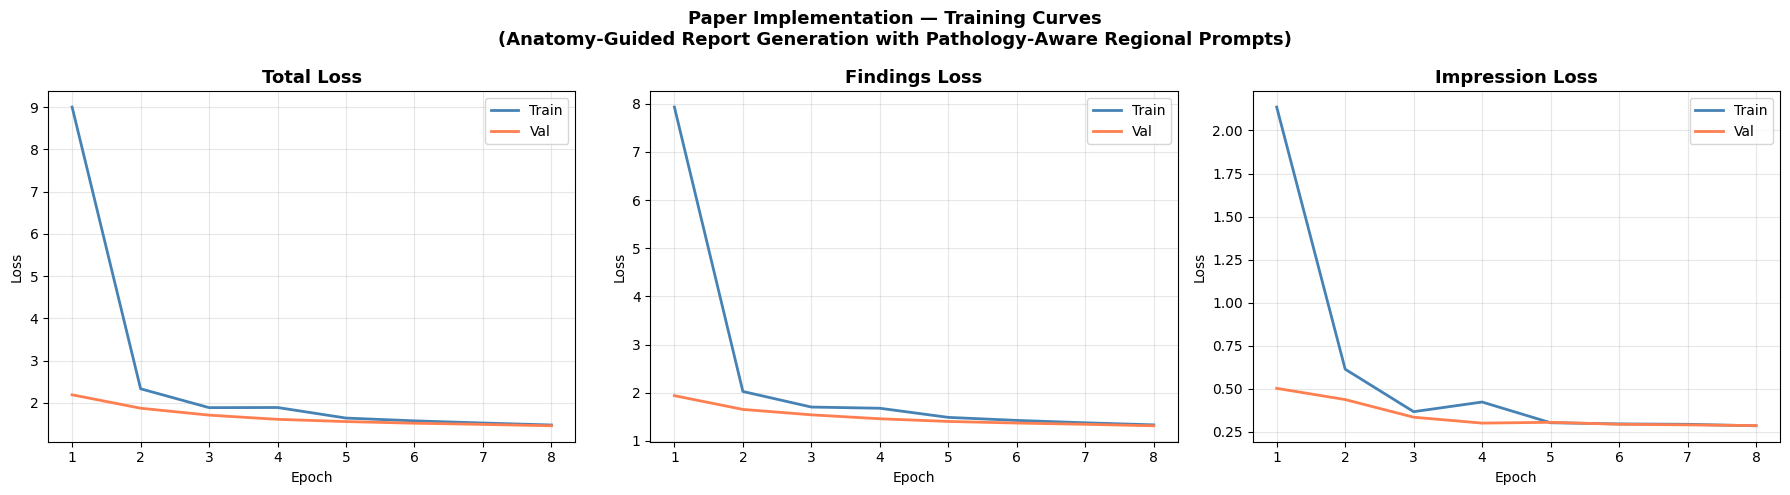

Training curves and history saved!


In [20]:
import torch
import json
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import evaluate
from tqdm import tqdm


MODEL_PATH  = "/kaggle/input/models/cynthia30/best-model-abscomp/pytorch/default/1/paper_model_best_absoluteComp.pt"


checkpoint  = torch.load(MODEL_PATH, map_location=DEVICE)

model.load_state_dict(checkpoint["model_state"])
model.eval()

history       = checkpoint["history"]
best_val_loss = checkpoint["val_loss"]
epochs_ran    = len(history["train_total"])

print(f"✓ Model loaded!")
print(f"  Saved at epoch : {checkpoint['epoch']}")
print(f"  Best val loss  : {best_val_loss:.4f}")
print(f"  Epochs in hist : {epochs_ran}")





fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_x = range(1, len(history["train_total"]) + 1)

for ax, title, tk, vk in zip(
    axes,
    ["Total Loss", "Findings Loss", "Impression Loss"],
    ["train_total", "train_findings", "train_impression"],
    ["val_total",   "val_findings",   "val_impression"]
):
    ax.plot(epochs_x, history[tk], label="Train", color="steelblue", lw=2)
    ax.plot(epochs_x, history[vk], label="Val",   color="coral",     lw=2)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Paper Implementation — Training Curves\n"
             "(Anatomy-Guided Report Generation with Pathology-Aware Regional Prompts)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "paper_training_curves.png"), dpi=120)
plt.show()

with open(os.path.join(SAVE_PATH, "paper_history.json"), "w") as f:
    json.dump(history, f, indent=2)
print("Training curves and history saved!")

In [ ]:
best_model_path  = "/kaggle/input/models/cynthia30/best-model-abscomp/pytorch/default/1/paper_model_best_absoluteComp.pt"



ckpt = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Best model loaded — epoch {ckpt['epoch']}, val_loss={ckpt['val_loss']:.4f}")

@torch.no_grad()
def generate_reports(model, images, section="findings"):
    """
    Paper Section IV-B: beam search width=4 for inference.
    """
    images          = images.to(DEVICE)
    region_features, _ = model.region_detector(images)
    lesion_logits, lesion_probs = model.lesion_detector(images)
    region_tokens   = model.lesion_detector.get_dominant_lesion_per_region(
                          lesion_probs, NUM_REGIONS)
    prompt_features = model.prompt_module(region_features, region_tokens)

    decoder = (model.findings_decoder if section == "findings"
               else model.impression_decoder)

    
    return decoder.beam_search(region_features, prompt_features,
                                beam_width=BEAM_WIDTH)


_batch    = next(iter(val_loader))
_gen_f    = generate_reports(model, _batch["image"], section="findings")
_gen_i    = generate_reports(model, _batch["image"], section="impression")
_ref_f    = tokenizer.decode(_batch["findings_ids"][0], skip_special_tokens=True)
_ref_i    = tokenizer.decode(_batch["impression_ids"][0], skip_special_tokens=True)

print("\n=== Generation Sample ===")
print(f"REF Findings   : {_ref_f[:200]}")
print(f"GEN Findings   : {_gen_f[0][:200]}")
print(f"\nREF Impression : {_ref_i[:150]}")
print(f"GEN Impression : {_gen_i[0][:150]}")

Best model loaded — epoch 8, val_loss=1.4575

=== Generation Sample ===
REF Findings   : single portable view of the chest. lower lung volumes seen on the current exam. patchy region of opacity identified at the left lung base. elsewhere, the lungs are clear. the cardiomediastinal silhoue
GEN Findings   : the lungs are clear. the cardiomediastinal silhouette is within normal limits. no acute osseous abnormalities.

REF Impression : ' lung opacity '
GEN Impression : ' no finding '


In [ ]:
rouge_metric = evaluate.load("rouge")

def compute_metrics(preds, refs):
    """Compute BLEU-1, BLEU-4, ROUGE-L — same as paper's automated metrics."""
    tok_p = [p.split() for p in preds]
    tok_r = [[r.split()] for r in refs]
    sm    = SmoothingFunction().method1
    b1    = corpus_bleu(tok_r, tok_p, weights=(1,0,0,0),         smoothing_function=sm)
    b4    = corpus_bleu(tok_r, tok_p, weights=(.25,.25,.25,.25),  smoothing_function=sm)
    rl    = rouge_metric.compute(predictions=preds, references=refs)["rougeL"]
    return {"bleu1": b1, "bleu4": b4, "rouge_l": rl}

f_preds, f_refs   = [], []
i_preds, i_refs   = [], []

print(f"Evaluating on {len(test_dataset):,} test samples...")
for bidx, batch in enumerate(test_loader):
    f_preds.extend(generate_reports(model, batch["image"], "findings"))
    i_preds.extend(generate_reports(model, batch["image"], "impression"))
    f_refs.extend([tokenizer.decode(ids, skip_special_tokens=True)
                   for ids in batch["findings_ids"]])
    i_refs.extend([tokenizer.decode(ids, skip_special_tokens=True)
                   for ids in batch["impression_ids"]])
    if bidx % 30 == 0:
        print(f"  {bidx * BATCH_SIZE:,} / {len(test_dataset):,}")

f_metrics = compute_metrics(f_preds, f_refs)
i_metrics = compute_metrics(i_preds, i_refs)

print("\n" + "=" * 55)
print("NLG METRICS — Paper Implementation")
print("=" * 55)
print(f"\nFINDINGS:")
print(f"  BLEU-1  : {f_metrics['bleu1']:.4f}")
print(f"  BLEU-4  : {f_metrics['bleu4']:.4f}")
print(f"  ROUGE-L : {f_metrics['rouge_l']:.4f}")
print(f"\nIMPRESSION (added for comparison with novel model):")
print(f"  BLEU-1  : {i_metrics['bleu1']:.4f}")
print(f"  BLEU-4  : {i_metrics['bleu4']:.4f}")
print(f"  ROUGE-L : {i_metrics['rouge_l']:.4f}")

Evaluating on 1,489 test samples...
  0 / 1,489
  240 / 1,489
  480 / 1,489
  720 / 1,489
  960 / 1,489
  1,200 / 1,489
  1,440 / 1,489

NLG METRICS — Paper Implementation

FINDINGS:
  BLEU-1  : 0.1928
  BLEU-4  : 0.0421
  ROUGE-L : 0.1936

IMPRESSION (added for comparison with novel model):
  BLEU-1  : 0.5885
  BLEU-4  : 0.4432
  ROUGE-L : 0.4757


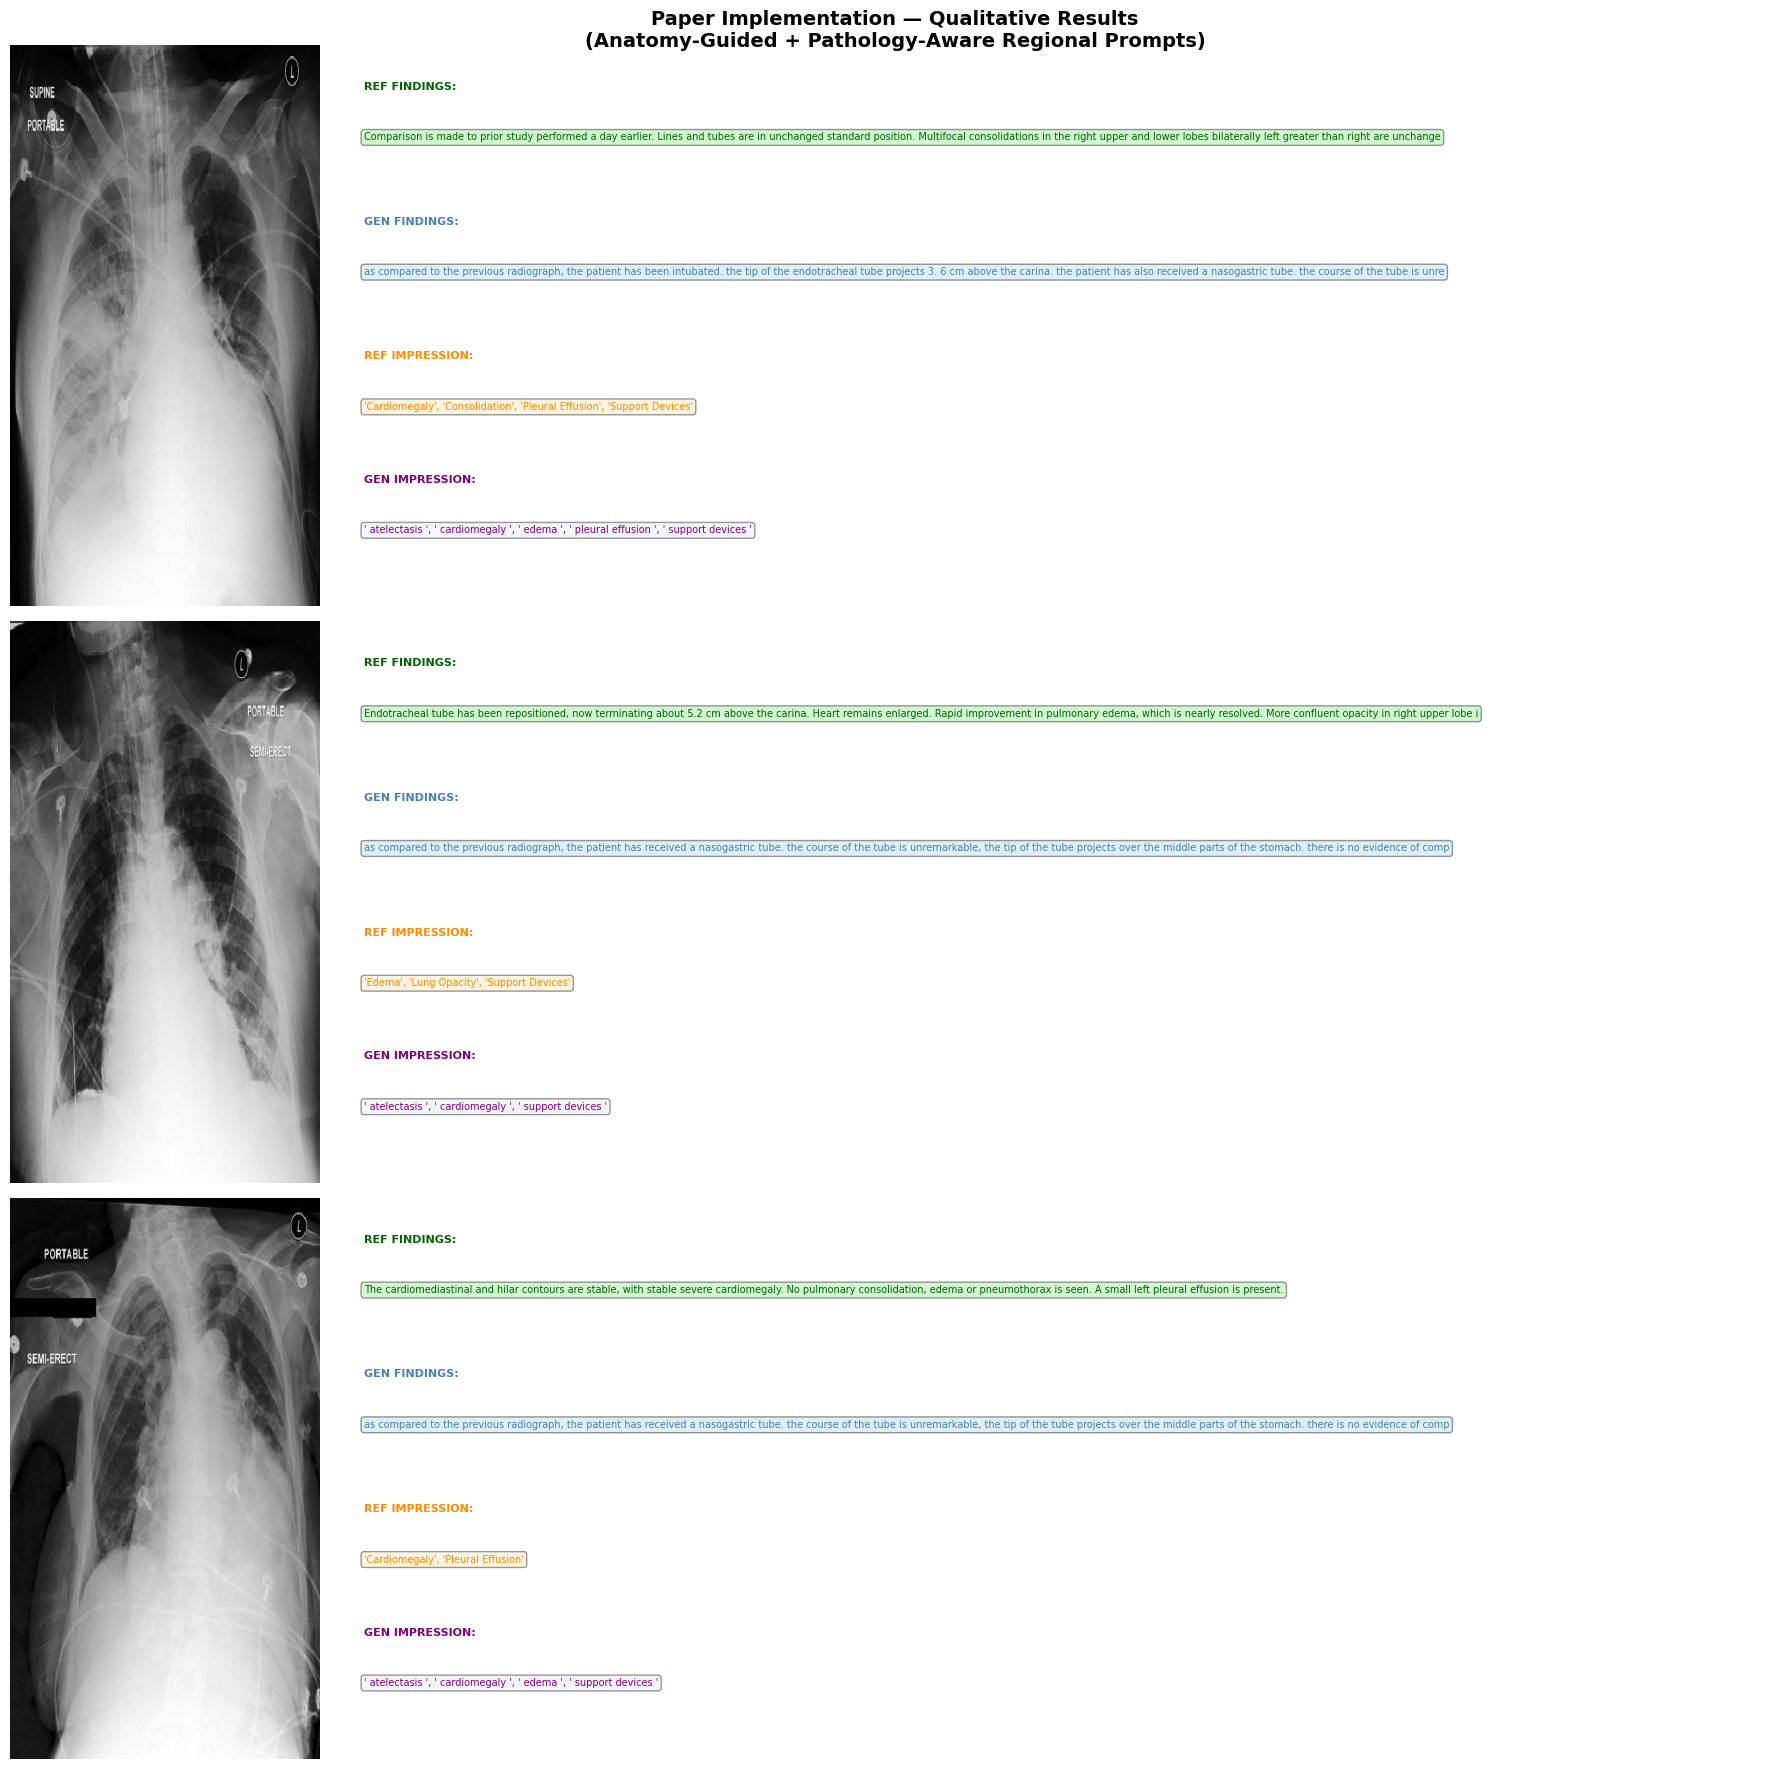

Qualitative results saved!


In [25]:
fig, axes = plt.subplots(3, 1, figsize=(18, 18))

for ax, idx in zip(axes, [0, 100, 200]):
    img  = Image.open(test_df.iloc[idx]["path"]).convert("RGB")
    ax.imshow(img, cmap="gray", aspect="auto", extent=[0, 3.5, 0, 10])
    ax.set_xlim(0, 20); ax.set_ylim(0, 10); ax.axis("off")

    tx = 4.0
    for y, label, text, color, bg in [
        (9.2, "REF FINDINGS:",    test_df.iloc[idx]['findings'][:220],   "darkgreen",  "lightgreen"),
        (6.8, "GEN FINDINGS:",    f_preds[idx][:220],                    "steelblue",  "lightblue"),
        (4.4, "REF IMPRESSION:",  test_df.iloc[idx]['impression'][:150],  "darkorange", "moccasin"),
        (2.2, "GEN IMPRESSION:",  i_preds[idx][:150],                    "purple",     "lavender"),
    ]:
        ax.text(tx, y,        label, fontsize=8,  fontweight="bold", color=color)
        ax.text(tx, y - 0.9,  text,  fontsize=7,  color=color,
                bbox=dict(boxstyle="round", facecolor=bg, alpha=0.4))

plt.suptitle("Paper Implementation — Qualitative Results\n"
             "(Anatomy-Guided + Pathology-Aware Regional Prompts)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "paper_qualitative.png"), dpi=100)
plt.show()
print("Qualitative results saved!")

Analysing lesion detection on test set...


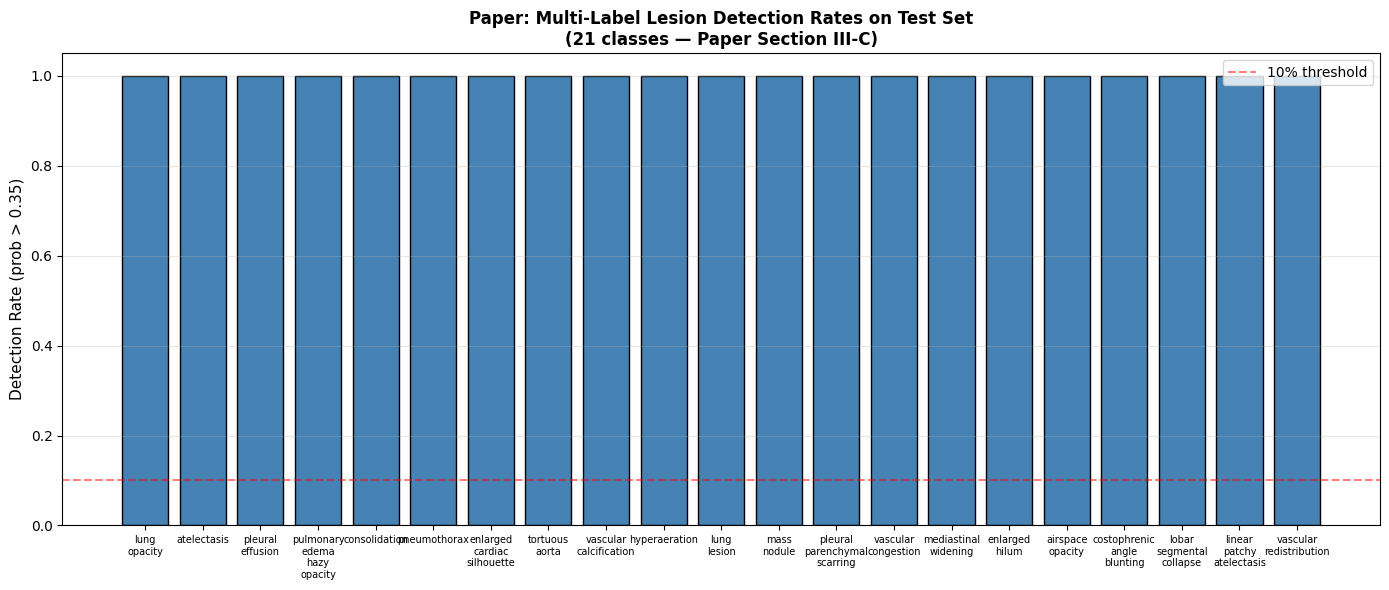


Top 5 most detected lesions:
  vascular_redistribution                  : 1.000
  linear_patchy_atelectasis                : 1.000
  lobar_segmental_collapse                 : 1.000
  costophrenic_angle_blunting              : 1.000
  airspace_opacity                         : 1.000


In [ ]:

print("Analysing lesion detection on test set...")
all_probs = []
model.eval()

with torch.no_grad():
    for batch in test_loader:
        imgs = batch["image"].to(DEVICE)
        _, lp = model.lesion_detector(imgs)
        all_probs.append(lp.cpu())

all_probs = torch.cat(all_probs, dim=0).numpy()  
detection_rate = (all_probs >= CONFIDENCE_THRESHOLD).mean(axis=0)  

fig, ax = plt.subplots(figsize=(14, 6))
colors  = ["steelblue" if r > 0.1 else "lightgray" for r in detection_rate]
bars    = ax.bar(range(NUM_LESIONS), detection_rate, color=colors, edgecolor="black")
ax.set_xticks(range(NUM_LESIONS))
ax.set_xticklabels([c.replace("_", "\n") for c in LESION_CLASSES],
                   fontsize=7, rotation=0)
ax.set_ylabel("Detection Rate (prob > 0.35)", fontsize=11)
ax.set_title("Paper: Multi-Label Lesion Detection Rates on Test Set\n"
             "(21 classes — Paper Section III-C)",
             fontsize=12, fontweight="bold")
ax.axhline(y=0.1, color="red", linestyle="--", alpha=0.5, label="10% threshold")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "paper_lesion_detection.png"), dpi=120)
plt.show()

print("\nTop 5 most detected lesions:")
top5_idx = detection_rate.argsort()[::-1][:5]
for i in top5_idx:
    print(f"  {LESION_CLASSES[i]:40s} : {detection_rate[i]:.3f}")

In [ ]:

print("=" * 60)
print("ABLATION STUDY (Paper Section IV-G)")
print("=" * 60)

class AblationDecoder(nn.Module):
    """Baseline decoder: receives only visual features, no prompt."""
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.base = BERTDecoder(vocab_size=vocab_size, d_model=d_model)

    def forward(self, region_features, input_ids, attention_mask, labels=None):
        
        null_prompt = torch.zeros_like(region_features)
        return self.base(region_features, null_prompt, input_ids,
                         attention_mask, labels)

ablation_decoder = AblationDecoder(VOCAB_SIZE, BERT_HIDDEN).to(DEVICE)
ablation_decoder.load_state_dict(
    model.findings_decoder.state_dict(), strict=False
)
ablation_decoder.eval()

abl_losses = []
with torch.no_grad():
    for i, batch in enumerate(val_loader):
        if i >= 50: break
        imgs = batch["image"].to(DEVICE)
        fids = batch["findings_ids"].to(DEVICE)
        fmsk = batch["findings_mask"].to(DEVICE)

        rf, _ = model.region_detector(imgs)
        _, lp = model.lesion_detector(imgs)

        rt  = model.lesion_detector.get_dominant_lesion_per_region(lp, NUM_REGIONS)
        pf  = model.prompt_module(rf, rt)
        _, full_loss = model.findings_decoder(rf, pf, fids, fmsk, labels=fids)

        _, base_loss = ablation_decoder(rf, fids, fmsk, labels=fids)

        abl_losses.append((full_loss.item(), base_loss.item()))

full_avg = sum(x[0] for x in abl_losses) / len(abl_losses)
base_avg = sum(x[1] for x in abl_losses) / len(abl_losses)

print(f"\nAblation on first 50 validation batches:")
print(f"  Baseline (no prompt)          : val_findings_loss = {base_avg:.4f}")
print(f"  +Pathology-Aware Prompt (ours): val_findings_loss = {full_avg:.4f}")
print(f"  Improvement from PARP         : {base_avg - full_avg:+.4f}")
print(f"\n  Paper Table IV reports F1 improvement of +8.9% from PARP")
print(f"  (Our metric is loss; lower = better)")

ABLATION STUDY (Paper Section IV-G)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(



Ablation on first 50 validation batches:
  Baseline (no prompt)          : val_findings_loss = 371.1846
  +Pathology-Aware Prompt (ours): val_findings_loss = 1.3193
  Improvement from PARP         : +369.8653

  Paper Table IV reports F1 improvement of +8.9% from PARP
  (Our metric is loss; lower = better)


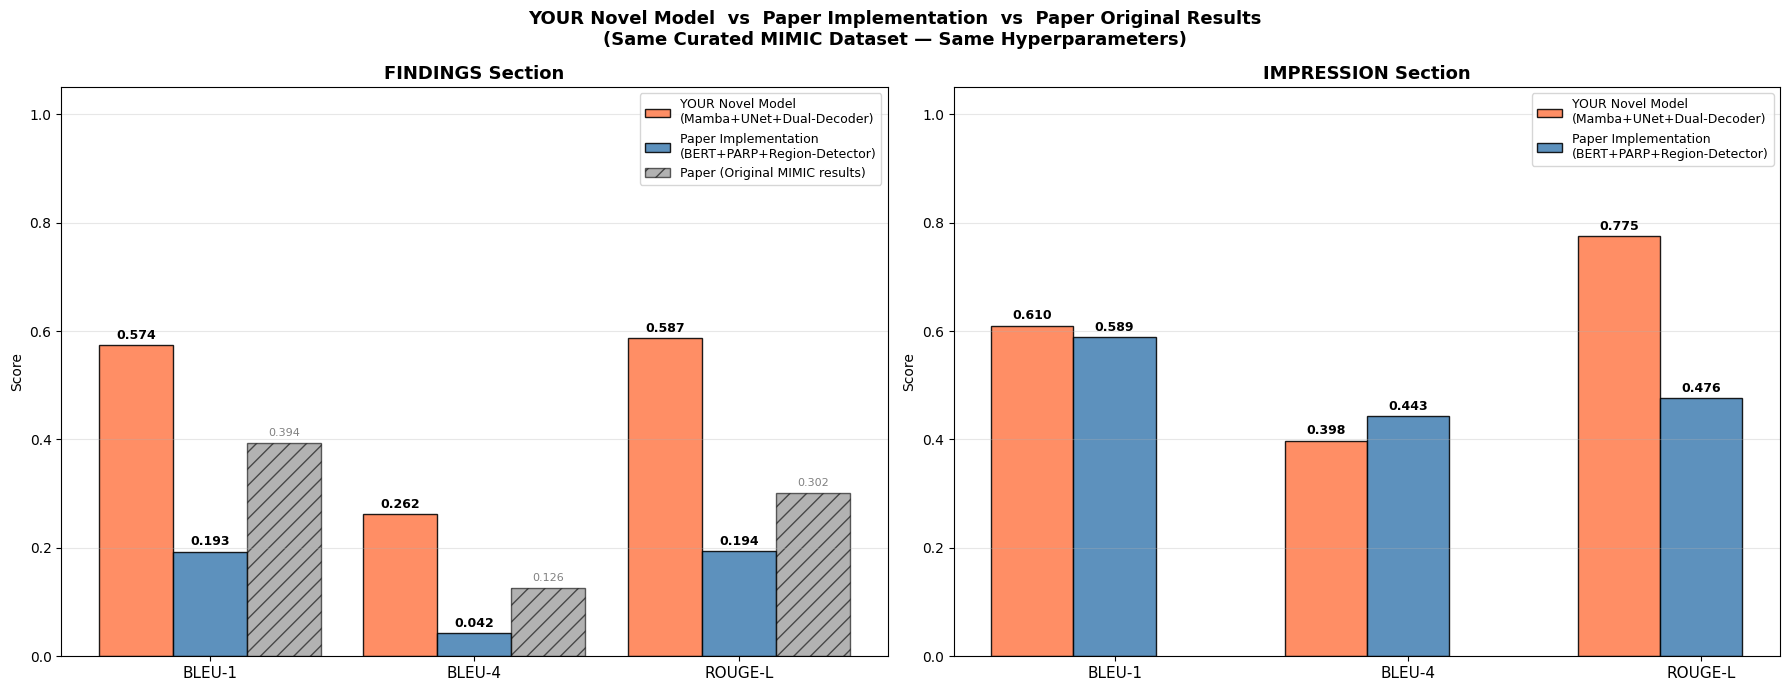

Final comparison chart saved!


In [ ]:

YOUR_METRICS = {
    "findings_bleu1" : 0.5738,
    "findings_bleu4" : 0.2617,
    "findings_rouge" : 0.5865,
    "impress_bleu1"  : 0.6098,
    "impress_bleu4"  : 0.3976,
    "impress_rouge"  : 0.7751,
}

PAPER_ORIGINAL = {
    "findings_bleu1" : 0.394,
    "findings_bleu4" : 0.126,
    "findings_rouge" : 0.302,
}

PAPER_OURS = {
    "findings_bleu1" : f_metrics["bleu1"],
    "findings_bleu4" : f_metrics["bleu4"],
    "findings_rouge" : f_metrics["rouge_l"],
    "impress_bleu1"  : i_metrics["bleu1"],
    "impress_bleu4"  : i_metrics["bleu4"],
    "impress_rouge"  : i_metrics["rouge_l"],
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
metrics_lbl = ["BLEU-1", "BLEU-4", "ROUGE-L"]
x           = np.arange(len(metrics_lbl))
w           = 0.28

for ax, section, y_keys in [
    (axes[0], "FINDINGS",   ["findings_bleu1", "findings_bleu4", "findings_rouge"]),
    (axes[1], "IMPRESSION", ["impress_bleu1",  "impress_bleu4",  "impress_rouge"]),
]:
    your_vals  = [YOUR_METRICS[k] for k in y_keys]
    paper_vals = [PAPER_OURS[k]   for k in y_keys]

    b1 = ax.bar(x - w, your_vals,  w, label="YOUR Novel Model\n(Mamba+UNet+Dual-Decoder)",
                color="coral",     alpha=0.88, edgecolor="black")
    b2 = ax.bar(x,     paper_vals, w, label="Paper Implementation\n(BERT+PARP+Region-Detector)",
                color="steelblue", alpha=0.88, edgecolor="black")

    if section == "FINDINGS":
        orig_vals = [PAPER_ORIGINAL[k] for k in y_keys]
        b3 = ax.bar(x + w, orig_vals, w, label="Paper (Original MIMIC results)",
                    color="grey", alpha=0.60, edgecolor="black", hatch="//")
        for bar in b3:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.012,
                    f"{bar.get_height():.3f}", ha="center", fontsize=8, color="grey")

    for bar in b1:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.012,
                f"{bar.get_height():.3f}", ha="center", fontsize=9, fontweight="bold")
    for bar in b2:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.012,
                f"{bar.get_height():.3f}", ha="center", fontsize=9, fontweight="bold")

    ax.set_title(f"{section} Section", fontsize=13, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(metrics_lbl, fontsize=11)
    ax.set_ylim(0, 1.05); ax.set_ylabel("Score")
    ax.legend(fontsize=9, loc="upper right"); ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    "YOUR Novel Model  vs  Paper Implementation  vs  Paper Original Results\n"
    "(Same Curated MIMIC Dataset — Same Hyperparameters)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "final_comparison_chart.png"), dpi=130)
plt.show()
print("Final comparison chart saved!")

In [29]:
with open(os.path.join(SAVE_PATH, "paper_metrics.json"), "w") as f:
    json.dump({
        "paper_our_run": {
            "findings"   : {k: round(v, 4) for k, v in f_metrics.items()},
            "impression" : {k: round(v, 4) for k, v in i_metrics.items()}
        },
        "paper_original_mimic": {
            "findings": PAPER_ORIGINAL
        },
        "your_novel_model": YOUR_METRICS
    }, f, indent=2)

print("=" * 65)
print("FINAL SUMMARY — Paper vs Your Novel Model")
print("=" * 65)
print(f"""
┌──────────────────────┬────────────┬────────────┬────────────┐
│ Metric               │Paper(ours) │Paper(orig) │YOUR Model  │
├──────────────────────┼────────────┼────────────┼────────────┤
│ Findings BLEU-1      │ {f_metrics['bleu1']:.4f}     │ 0.3940     │ 0.5738     │
│ Findings BLEU-4      │ {f_metrics['bleu4']:.4f}     │ 0.1260     │ 0.2617     │
│ Findings ROUGE-L     │ {f_metrics['rouge_l']:.4f}     │ 0.3020     │ 0.5865     │
├──────────────────────┼────────────┼────────────┼────────────┤
│ Impression BLEU-1    │ {i_metrics['bleu1']:.4f}     │    N/A     │ 0.6098     │
│ Impression BLEU-4    │ {i_metrics['bleu4']:.4f}     │    N/A     │ 0.3976     │
│ Impression ROUGE-L   │ {i_metrics['rouge_l']:.4f}     │    N/A     │ 0.7751     │
└──────────────────────┴────────────┴────────────┴────────────┘

ARCHITECTURE DIFFERENCES:
  Paper : Faster R-CNN region detector  + YOLOv5 lesion detector
          + BERT decoder  + pathology-aware prompt (29 regions, 21 lesions)
  Yours : U-Net+CBAM segmentation masks + Mamba SSM encoder (NOVELTY)
          + GPT-2 dual decoder (Findings+Impression conditioned) (NOVELTY)
          + No explicit lesion detector (spatial routing only) (NOVELTY)

DATASET: Both use curated MIMIC. Epochs={EPOCHS}, Batch={BATCH_SIZE}.
""")

print("All outputs saved to:", SAVE_PATH)
for fname in sorted(os.listdir(SAVE_PATH)):
    size = os.path.getsize(os.path.join(SAVE_PATH, fname)) / 1e6
    print(f"  {fname:45s} {size:.1f} MB")

FINAL SUMMARY — Paper vs Your Novel Model

┌──────────────────────┬────────────┬────────────┬────────────┐
│ Metric               │Paper(ours) │Paper(orig) │YOUR Model  │
├──────────────────────┼────────────┼────────────┼────────────┤
│ Findings BLEU-1      │ 0.1928     │ 0.3940     │ 0.5738     │
│ Findings BLEU-4      │ 0.0421     │ 0.1260     │ 0.2617     │
│ Findings ROUGE-L     │ 0.1936     │ 0.3020     │ 0.5865     │
├──────────────────────┼────────────┼────────────┼────────────┤
│ Impression BLEU-1    │ 0.5885     │    N/A     │ 0.6098     │
│ Impression BLEU-4    │ 0.4432     │    N/A     │ 0.3976     │
│ Impression ROUGE-L   │ 0.4757     │    N/A     │ 0.7751     │
└──────────────────────┴────────────┴────────────┴────────────┘

ARCHITECTURE DIFFERENCES:
  Paper : Faster R-CNN region detector  + YOLOv5 lesion detector
          + BERT decoder  + pathology-aware prompt (29 regions, 21 lesions)
  Yours : U-Net+CBAM segmentation masks + Mamba SSM encoder (NOVELTY)
          + GPT